In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import pandas as pd
import mplcursors
from IPython.display import display

# Backend interactivo: widget (JupyterLab) → notebook (Jupyter clásico)
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'notebook')

plt.rcParams['figure.figsize'] = [8, 6]


# Formatear complejos como a \pm jb
def fmt_complex(z):
    r, i = z.real, z.imag
    if abs(i) < 1e-6:
        return f'{r:.4f}'
    sign = '+' if i >= 0 else '-'
    return f'{r:.4f} {sign} j{abs(i):.4f}'

# Construir tabla LaTeX
latex = r'$$\begin{array}{c|ccc}' + '\n'
latex += r'k_p & p_1 & p_2 & p_3 \\' + '\n'
latex += r'\hline' + '\n'
for k, p1, p2, p3 in zip(k_vals, p1_vals, p2_vals, p3_vals):
    cols = [f'{k:.4f}', fmt_complex(p1), fmt_complex(p2), fmt_complex(p3)]
    latex += ' & '.join(cols) + r' \\' + '\n'
latex += r'\end{array}$$'

# Lugar de las raíces para el diseño de sistemas realimentados


## Tabla de contenidos
  [Ejemplo 1: levitador](#H_2382D06F)

    [**Actividad 1: Use el lugar de las raíces para diseñar un controlador proporcional en cada uno de los siguientes casos**](#H_066B7F8E)


   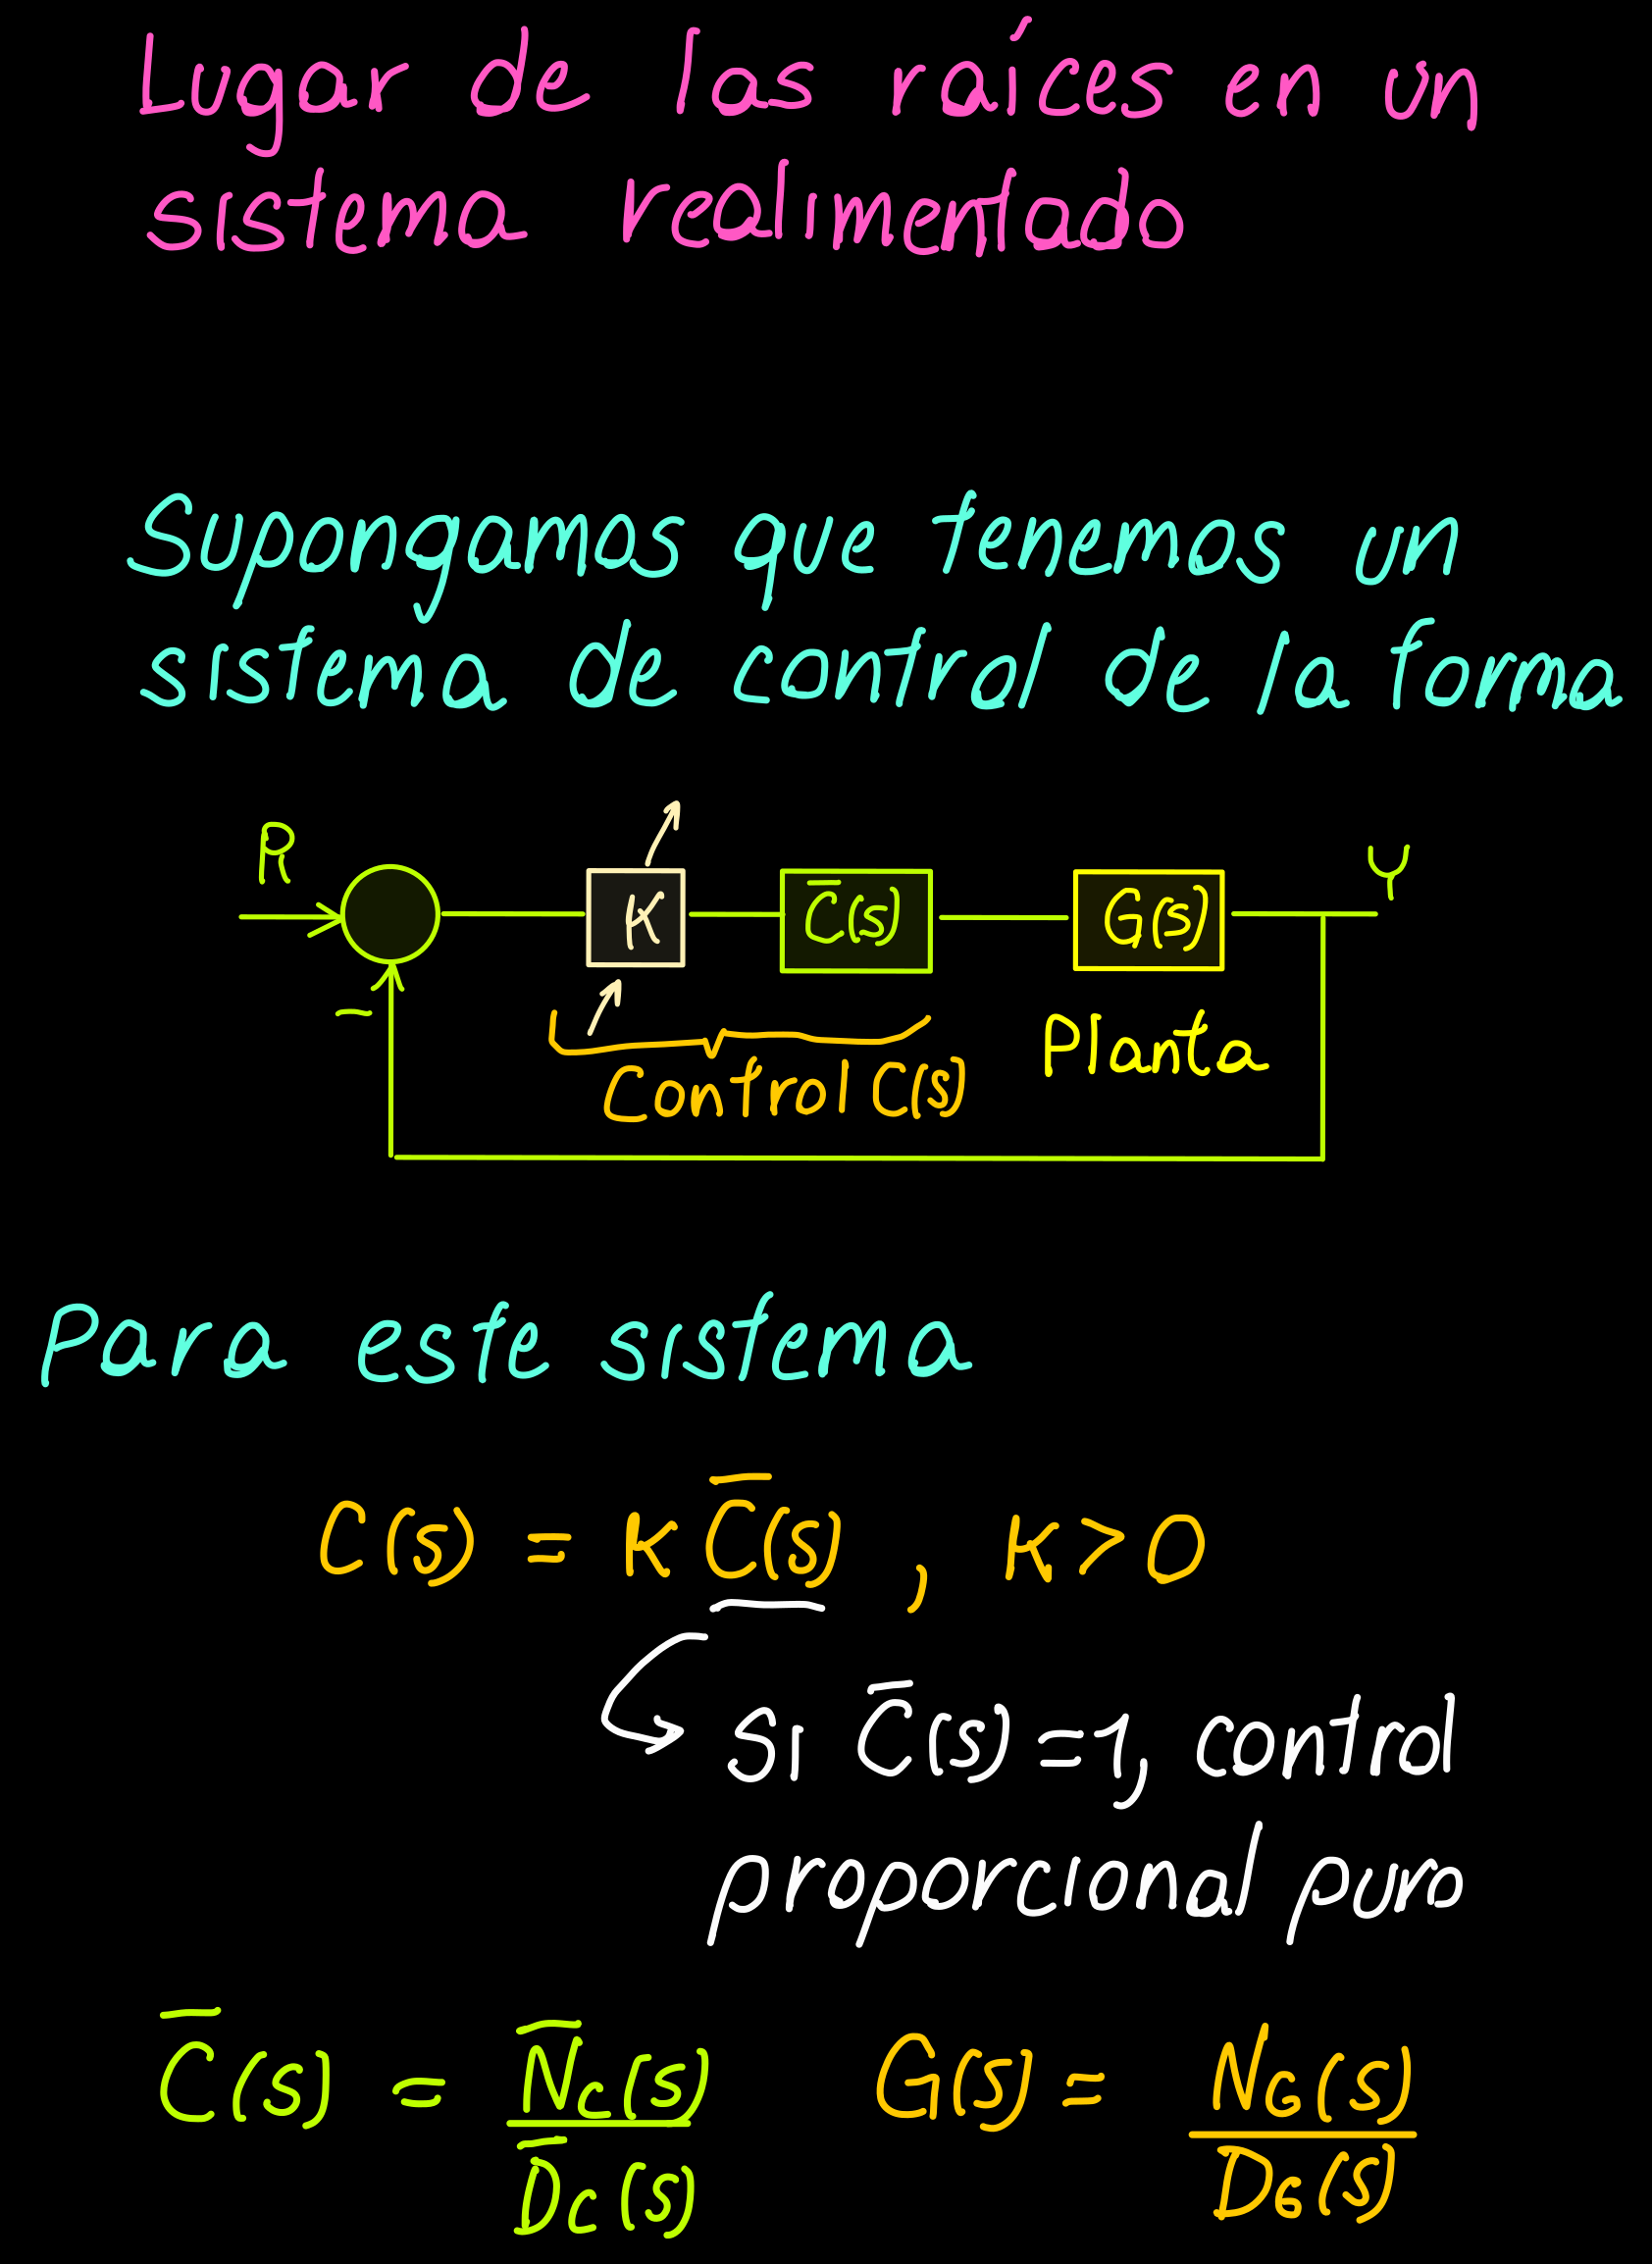


   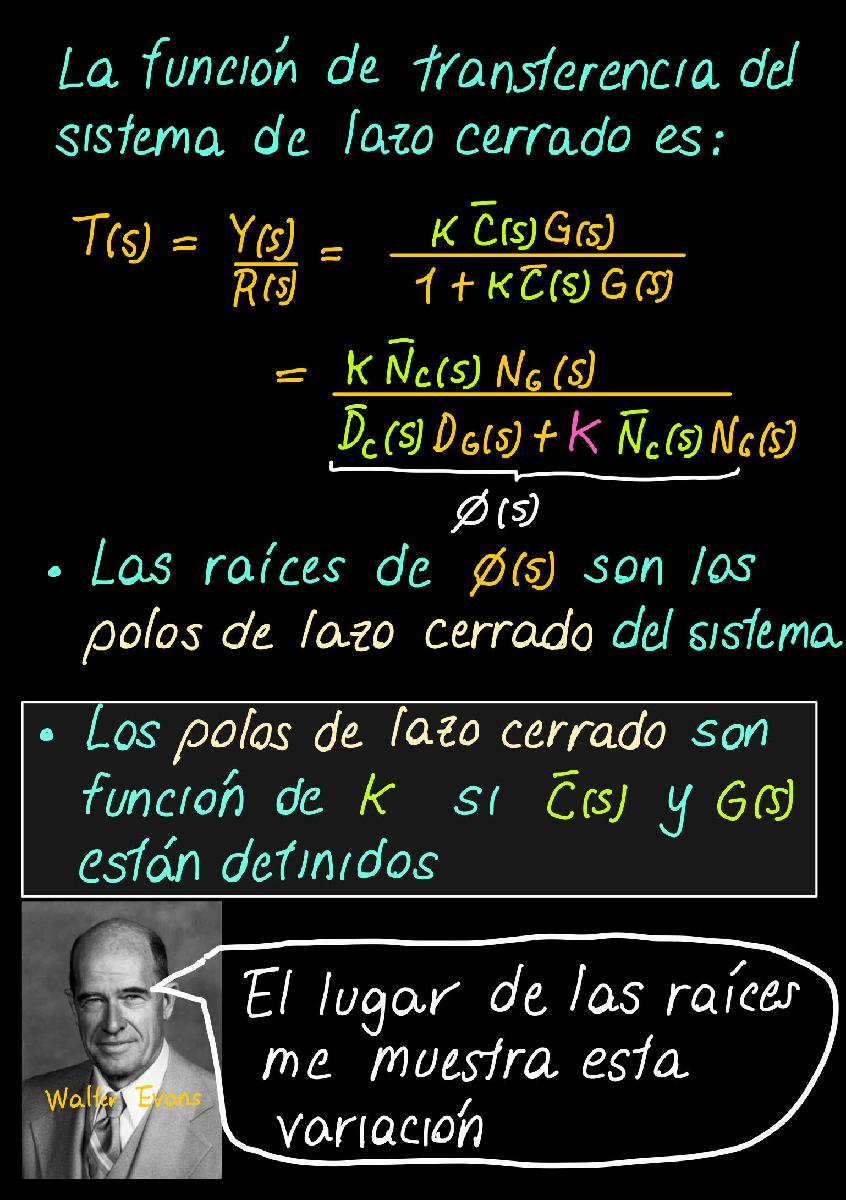


## Ejemplo 1: levitador

Supongamos que queremos diseñar un controlador para el levitador cuya función de transferencia fue encontrada en la actividad 1 (con otros parámetros). Dicha función de transferencia está dada por la siguiente expresión:


$$G(s)=\frac{182.27}{s(s+2.28)(s+3.664)}$$

In [2]:
s = ctrl.tf('s')
G = 182.27 / (s * (s + 2.28) * (s + 3.664))

Supongamos que le colocamos un controlador proporcional,


In [ ]:
from IPython.display import Latex

kp0 = 0.01
kpf = 0.39
points = 10
KP = np.linspace(kp0, kpf, points)

k_vals = []
p1_vals = []
p2_vals = []
p3_vals = []
for kp_i in KP:
    T = ctrl.feedback(kp_i * G, 1)
    poles = np.sort_complex(ctrl.poles(T))
    k_vals.append(kp_i)
    p1_vals.append(poles[0])
    p2_vals.append(poles[1])
    p3_vals.append(poles[2])

# Formatear complejos como a \pm jb
def fmt_complex(z):
    r, i = z.real, z.imag
    if abs(i) < 1e-6:
        return f'{r:.4f}'
    sign = '+' if i >= 0 else '-'
    return f'{r:.4f} {sign} j{abs(i):.4f}'

# Construir tabla LaTeX
latex = r'$$\begin{array}{c|ccc}' + '\n'
latex += r'k_p & p_1 & p_2 & p_3 \\' + '\n'
latex += r'\hline' + '\n'
for k, p1, p2, p3 in zip(k_vals, p1_vals, p2_vals, p3_vals):
    cols = [f'{k:.4f}', fmt_complex(p1), fmt_complex(p2), fmt_complex(p3)]
    latex += ' & '.join(cols) + r' \\' + '\n'
latex += r'\end{array}$$'

display(Latex(latex))


<IPython.core.display.Latex object>

Ahora vamos a dibujar la región de diseño con las especificaciones:


$$\begin{array}{l} t_{ee} \le 8s\newline t_r \le 4s\newline SP\le 10\newline  \end{array}$$


Para esto usamos las fórmulas de la región de diseño, vistas antes.


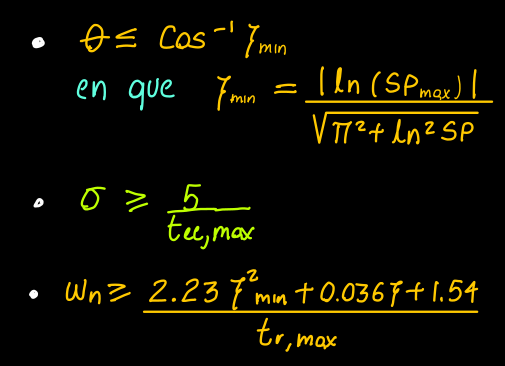


In [4]:
SP_max = 0.1
tee_max = 8
tr_max = 3
zeta_min = abs(np.log(SP_max)) / np.sqrt(np.pi**2 + np.log(SP_max)**2)
teta_max = np.arccos(zeta_min)
np.degrees(teta_max)

sigma_min = 5 / tee_max
print(f'sigma_min = {sigma_min}')

sigma_min = 0.625


In [5]:
wn_min = (2.23 * zeta_min**2 + 0.036 * zeta_min + 1.54) / tr_max
print(f'wn_min = {wn_min}  (mínimo wn)')

wn_min = 0.7801956374016802  (mínimo wn)


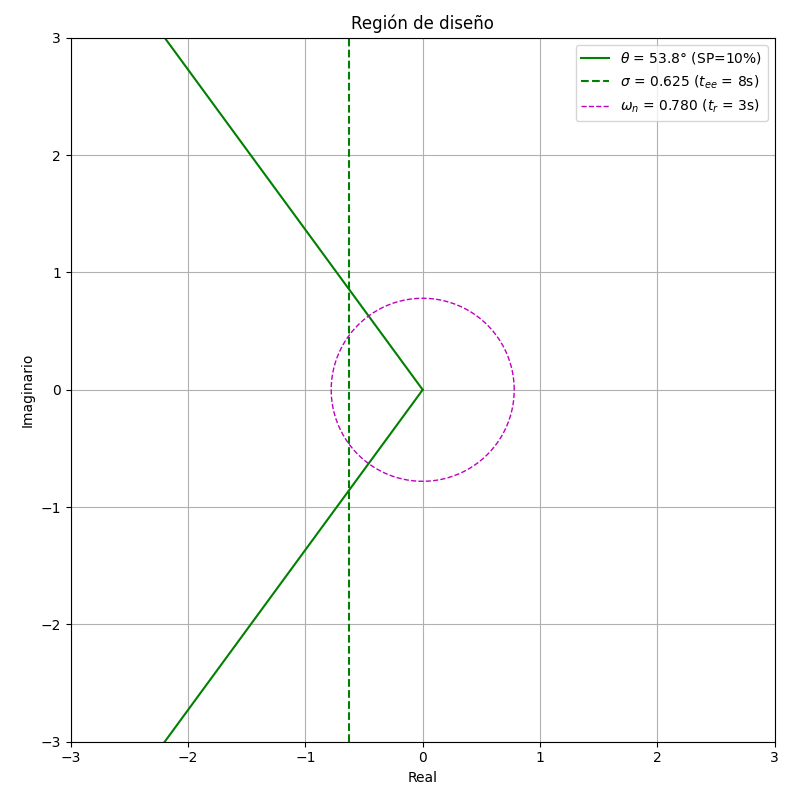

In [ ]:
dibujarRegionDiseno(wn_min, zeta_min, teta_max, sigma_min)


Supongamos que queremos los polos exactamente en el cruce de las lineas de la región de diseño de sobrepico y tiempo de establecimiento:


/usr/local/lib/python3.12/dist-packages/control/rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


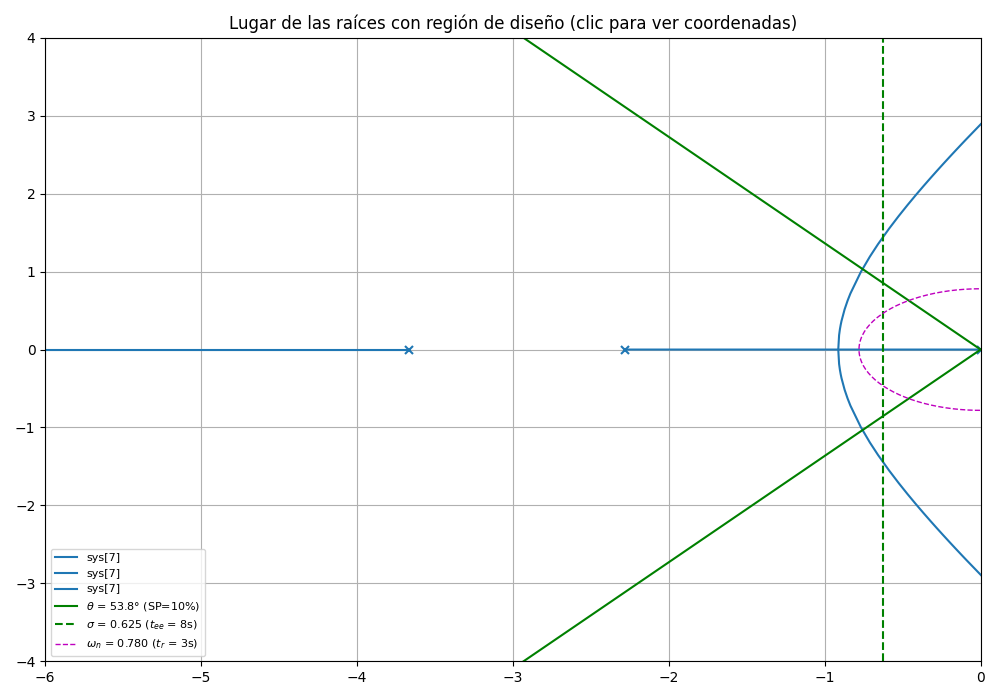

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
rlist, klist = ctrl.root_locus(G, plot=True, ax=ax)

# Superponer la región de diseño
dibujarRegionDiseno(wn_min, zeta_min, teta_max, sigma_min, ax=ax)

ax.set_xlim([-6, 0])
ax.set_ylim([-4, 4])
ax.set_title('Lugar de las raíces con región de diseño (clic para ver coordenadas)')
ax.grid(True)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()

# Habilitar cursor interactivo en TODAS las líneas del gráfico
lines = [line for line in ax.get_lines()]
cursor = mplcursors.cursor(lines, hover=False)

@cursor.connect('add')
def on_add(sel):
    x, y = sel.target
    if abs(y) < 1e-6:
        sel.annotation.set_text(f's = {x:.4f}')
    elif y >= 0:
        sel.annotation.set_text(f's = {x:.4f} + j{y:.4f}')
    else:
        sel.annotation.set_text(f's = {x:.4f} - j{abs(y):.4f}')
    sel.annotation.get_bbox_patch().set(fc='lightyellow', alpha=0.9)

plt.show()


Si queremos los polos dominantes en la intersección de la linea de sobrepico con la linea de tiempo de establecimiento, uno de los puntos complejos conjugados dominantes es


$$s_0 =-0.22+j0.29$$


In [8]:
s0 = -0.7

Por la condición de magnitud


In [9]:
k = abs((s0 * (s0 + 3.66) * (s0 + 2.28)) / 182.7)
print(f'k = {k}')

k = 0.017918773946360152


In [10]:
T = ctrl.feedback(k * G, 1)
print('Polos del sistema en lazo cerrado:')
print(ctrl.poles(T))

Polos del sistema en lazo cerrado:
[-4.10125587+0.j -1.15065714+0.j -0.69208698+0.j]


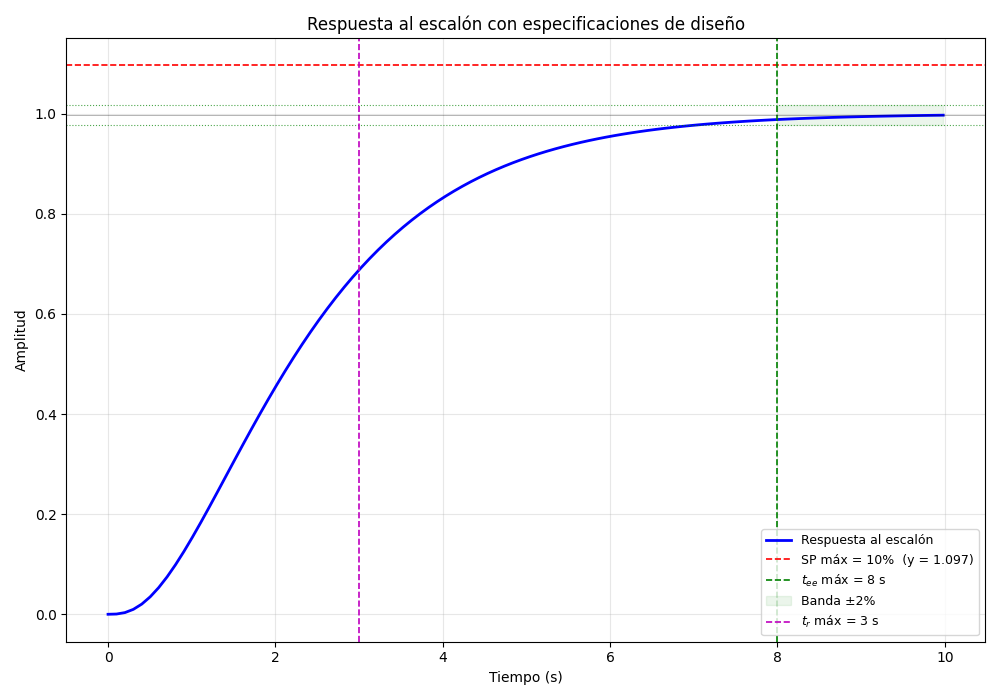

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
t, y = ctrl.step_response(T)
ax.plot(t, y, 'b', linewidth=2, label='Respuesta al escalón')

# Valor final (estado estacionario)
yss = y[-1]

# --- Especificación de sobrepico ---
y_sp = yss * (1 + SP_max)
ax.axhline(y=y_sp, color='r', linestyle='--', linewidth=1.2,
           label=f'SP máx = {SP_max*100:.0f}%  (y = {y_sp:.3f})')

# --- Especificación de tiempo de establecimiento ---
ax.axvline(x=tee_max, color='g', linestyle='--', linewidth=1.2,
           label=f'$t_{{ee}}$ máx = {tee_max} s')

# Banda de establecimiento (±2% del valor final, criterio del 2%)
banda = 0.02
ax.axhline(y=yss * (1 + banda), color='g', linestyle=':', linewidth=0.8, alpha=0.7)
ax.axhline(y=yss * (1 - banda), color='g', linestyle=':', linewidth=0.8, alpha=0.7)
ax.fill_between([tee_max, t[-1]], yss*(1 - banda), yss*(1 + banda),
                color='green', alpha=0.08, label=f'Banda ±{banda*100:.0f}%')

# --- Especificación de tiempo de subida ---
ax.axvline(x=tr_max, color='m', linestyle='--', linewidth=1.2,
           label=f'$t_r$ máx = {tr_max} s')

# Línea del valor final
ax.axhline(y=yss, color='k', linestyle='-', linewidth=0.5, alpha=0.4)

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Amplitud')
ax.set_title('Respuesta al escalón con especificaciones de diseño')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### **Actividad 1: Use el lugar de las raíces para diseñar un controlador proporcional en cada uno de los siguientes casos**
-  $\displaystyle SP_{max} \approx 5\%$
-  $\displaystyle SP=0$



In [12]:
# La función dibujarRegionDiseno ya fue definida e invocada en la celda anterior.